# BP神经网络手写数字识别实验报告
 
本文档在 Jupyter Notebook 中给出完整的实验过程与可复现实验代码，并在末尾提供一键导出 Word 实验报告的方法。
 
## 1  课题任务
### 1.1  任务内容
- 基于 MNIST 数据集，利用多层前馈 BP 神经网络实现手写体数字（0-9）的自动识别。
- 给出数据获取与预处理、探索性分析、建模训练、验证评估与结果分析的完整流程。
 
### 1.2  任务要求
- 正确读取与预处理 MNIST 数据；
- 构建含有至少一层隐藏层的 BP 神经网络；
- 给出训练过程的准确率/损失曲线；
- 在测试集上评估准确率，并给出混淆矩阵与分类报告；
- 提交可运行的 Jupyter Notebook 与 Word 实验报告。
 
## 2  数据说明与预处理
### 2.1  数据说明
- 数据集：MNIST，60000 张训练图片与 10000 张测试图片，灰度 28×28，类别为数字 0-9。
- 输入特征：将 28×28 像素拉平成 784 维向量。
- 标签：独热编码（one-hot）。
 
### 2.2  数据预处理
- 像素值归一化到 [0,1] 区间；
- 标签独热编码；
- 划分训练/测试集由数据集自带完成。
 
## 3  探索性分析
### 3.1  数字类别的分布情况
- 统计各数字类别在训练集与测试集中的样本数量并可视化。
 
### 3.2  遍历部分样本图片
- 展示若干随机样本与按类别取样的图片网格，直观了解数据特征。
 
## 4  分析建模
### 4.1  划分数据集
- 直接使用 MNIST 提供的训练/测试划分；必要时可从训练集中再切出验证集。
 
### 4.2  模型训练
- 使用 Keras Sequential 搭建 BP 网络（全连接层 + Sigmoid/Relu + Softmax）；
- 设置优化器（SGD/Adam）、损失函数（categorical_crossentropy），记录训练历史。
 
### 4.3  模型验证
- 在测试集上计算准确率；
- 生成分类报告和混淆矩阵热力图；
- 展示若干预测可视化（真值 vs 预测）。
 
### 4.4  结果分析
- 从正确率、混淆矩阵角度分析模型优缺点与易混类别。
 
## 5  总结
### 5.1  全文总结
- 总结数据、方法、结果与结论。
 
### 5.2  课设体会
- 反思工程实践过程中的收获与改进点。

In [3]:
# 导入依赖库
import os, random, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.optimizers import SGD, Adam
 
# 可重复性设置
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 只显示重要日志
random.seed(42)
np.random.seed(42)
try:
    import tensorflow as tf
    tf.random.set_seed(42)
except Exception as e:
    print('TensorFlow not available yet:', e)

In [2]:
# 可选：升级基础工具（使用 python -m pip 以兼容 Conda/虚拟环境）
import sys
!{sys.executable} -m pip install -U pip setuptools wheel
 
# 安装本实验所需依赖（CPU 环境下可直接安装 tensorflow）
!{sys.executable} -m pip install -U tensorflow keras matplotlib seaborn scikit-learn python-docx
 
import platform
print('Python:', sys.version)
print('Platform:', platform.platform())

  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)

  Attempting uninstall: setuptools

    Found existing installation: setuptools 79.0.1

    Uninstalling setuptools-79.0.1:

   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   ---------------------------------------- 0/2 [setuptools]
   -----------------------------

In [ ]:
> 环境说明：本实验依赖 tensorflow/keras、numpy、matplotlib、seaborn、scikit-learn、python-docx。若尚未安装，可先运行上一单元的安装命令。

In [4]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


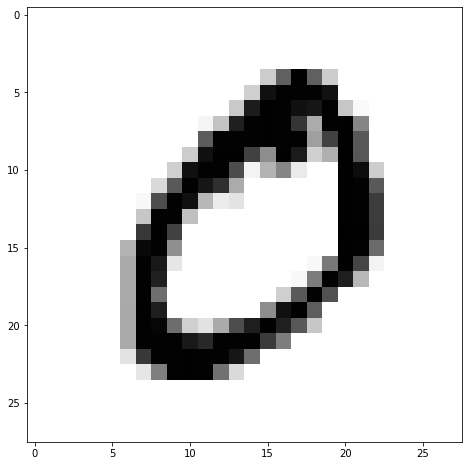

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
fig1=plt.figure(figsize=(8,8))
# fig1.subplots_adjust(left=0,right=1,bottom=0,top=1,hspace=0.05,wspace=0.05)
# ax=fig1.add_subplot(10,10,1,xticks=[],yticks=[])
plt.imshow(np.reshape(X_train[1], [28,28]),cmap=plt.cm.binary,interpolation='nearest')
    

C:\Users\31670\AppData\Local\Temp\ipykernel_7672\1805158341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette='tab10')
C:\Users\31670\AppData\Local\Temp\ipykernel_7672\1805158341.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, ax=axes[1], palette='tab10')
C:\Users\31670\AppData\Local\Temp\ipykernel_7672\1805158341.py:7: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31670\AppData\Local\Temp\ipykernel_7672\1805158341.py:7: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31670\AppData\Local\Temp

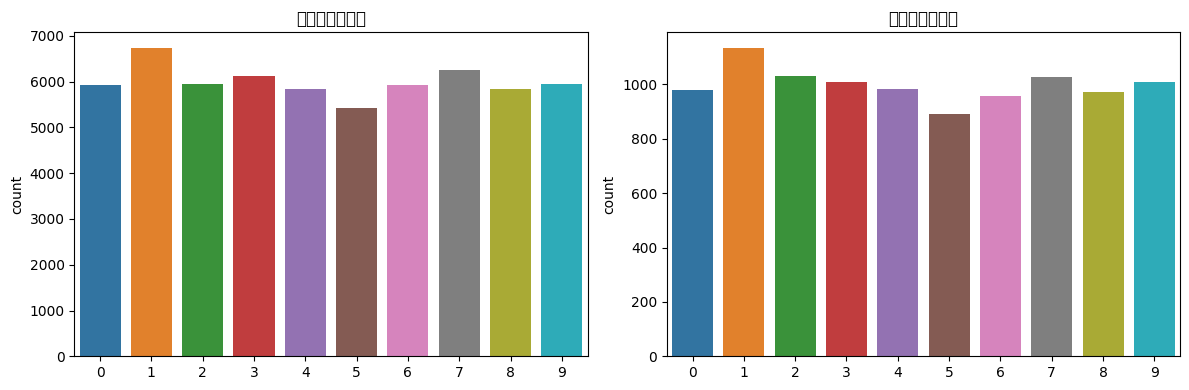

In [13]:
# 3.1 数字类别分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axes[0], palette='tab10')
axes[0].set_title('训练集类别分布')
sns.countplot(x=y_test, ax=axes[1], palette='tab10')
axes[1].set_title('测试集类别分布')
plt.tight_layout()
plt.show()

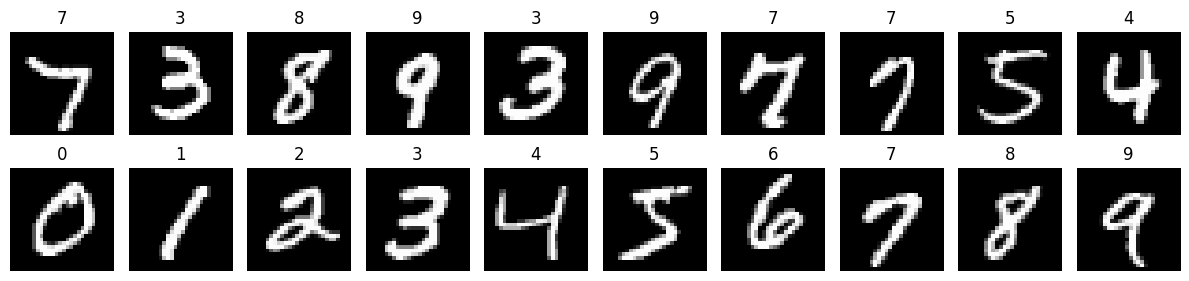

In [14]:
# 3.2 随机样本与按类别样本网格
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
# 随机 10 张
idx = np.random.choice(len(X_train), 10, replace=False)
for i, ax in enumerate(axes[0]):
    ax.imshow(np.reshape(X_train[idx[i]], (28, 28)), cmap='gray')
    ax.set_title(int(y_train[idx[i]]))
    ax.axis('off')
 
# 每个类别挑 1 张
for digit in range(10):
    ix = np.where(y_train == digit)[0][0]
    ax = axes[1][digit]
    ax.imshow(np.reshape(X_train[ix], (28, 28)), cmap='gray')
    ax.set_title(digit)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1]*X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1]*X_test.shape[2])
print(X_train.shape)
print(X_test.shape)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

(60000, 784)
(10000, 784)


In [7]:
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)
print('One-hot labels:', Y_train.shape, Y_test.shape)

One-hot labels: (60000, 10) (10000, 10)


In [8]:
model = Sequential() 
model.add(Dense(500, input_dim=784))
model.add(Activation('sigmoid'))
model.add(Dense(500))
model.add(Activation('sigmoid'))
model.add(Dense(10))
model.add(Activation('softmax'))

c:\Users\31670\anaconda3\envs\VisFactor\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,010 (2.47 MB)

 Trainable params: 648,010 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 建议使用交叉熵作为分类任务的损失函数
model.compile(loss='categorical_crossentropy', optimizer=SGD(learning_rate=0.1), metrics=['accuracy'])

In [11]:
history = model.fit(X_train, Y_train, batch_size=128, epochs=20, validation_split=0.1, verbose=2)

Epoch 1/20
422/422 - 5s - 12ms/step - accuracy: 0.4499 - loss: 1.7239 - val_accuracy: 0.7758 - val_loss: 0.8674
Epoch 2/20
422/422 - 5s - 12ms/step - accuracy: 0.4499 - loss: 1.7239 - val_accuracy: 0.7758 - val_loss: 0.8674
Epoch 2/20
422/422 - 3s - 7ms/step - accuracy: 0.8185 - loss: 0.6590 - val_accuracy: 0.8862 - val_loss: 0.4355
Epoch 3/20
422/422 - 3s - 7ms/step - accuracy: 0.8185 - loss: 0.6590 - val_accuracy: 0.8862 - val_loss: 0.4355
Epoch 3/20
422/422 - 3s - 7ms/step - accuracy: 0.8707 - loss: 0.4568 - val_accuracy: 0.9058 - val_loss: 0.3434
Epoch 4/20
422/422 - 3s - 7ms/step - accuracy: 0.8707 - loss: 0.4568 - val_accuracy: 0.9058 - val_loss: 0.3434
Epoch 4/20
422/422 - 3s - 7ms/step - accuracy: 0.8868 - loss: 0.3943 - val_accuracy: 0.9145 - val_loss: 0.3073
Epoch 5/20
422/422 - 3s - 7ms/step - accuracy: 0.8868 - loss: 0.3943 - val_accuracy: 0.9145 - val_loss: 0.3073
Epoch 5/20
422/422 - 3s - 7ms/step - accuracy: 0.8946 - loss: 0.3636 - val_accuracy: 0.9190 - val_loss: 0.2871

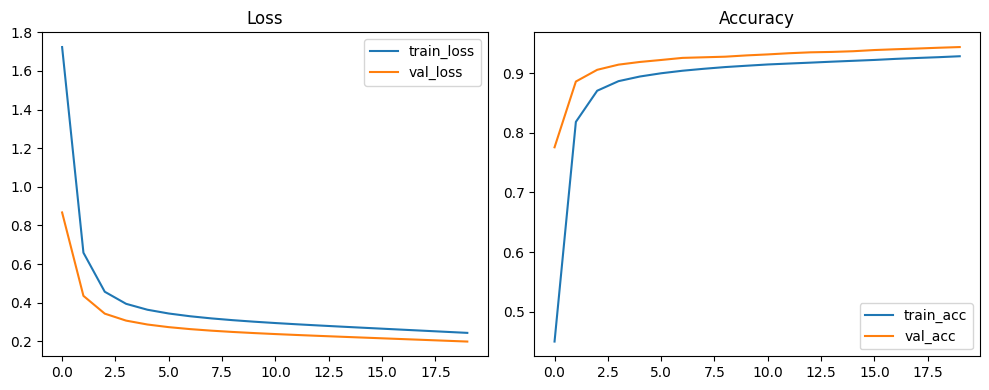

In [12]:
# 训练过程曲线
hist = history.history
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(hist['loss'], label='train_loss')
axes[0].plot(hist['val_loss'], label='val_loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(hist['accuracy'], label='train_acc')
axes[1].plot(hist['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [15]:
score = model.evaluate(X_test, Y_test)
print('Test loss: ', score[0])
print('Test accuracy: ', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9336 - loss: 0.2365
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9336 - loss: 0.2365
Test loss:  0.2365107387304306
Test accuracy:  0.9336000084877014
Test loss:  0.2365107387304306
Test accuracy:  0.9336000084877014


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0     0.9543    0.9796    0.9668       980
           1     0.9753    0.9744    0.9749      1135
           2     0.9422    0.9157    0.9287      1032
           3     0.9038    0.9396    0.9214      1010
           4     0.9176    0.9521    0.9345       982
           5     0.9415    0.8655    0.9019       892
           6     0.9344    0.9509    0.9426       958
           7     0.9420    0.9329    0.9374      1028
           8     0.8755    0.9240    0.8991       974
           9     0.9493    0.8910    0.9192      1009

    accuracy                         0.9336     10000
   macro avg     0.9336    0.9326    0.9326     10000
weighted avg     0.9342    0.9336    0.9335     10000



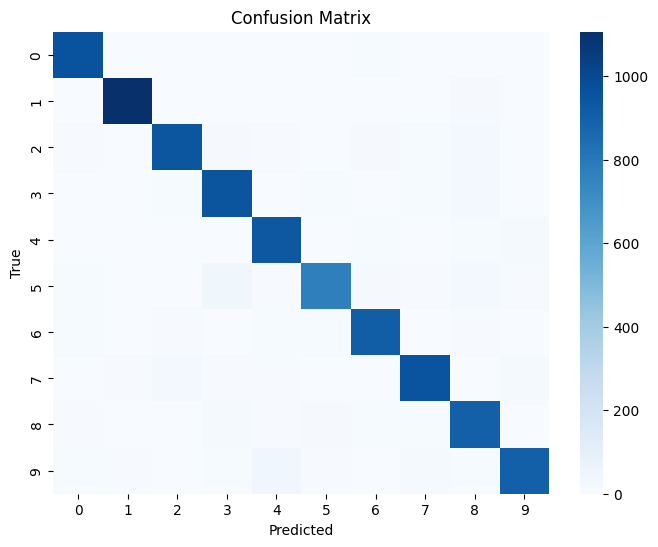

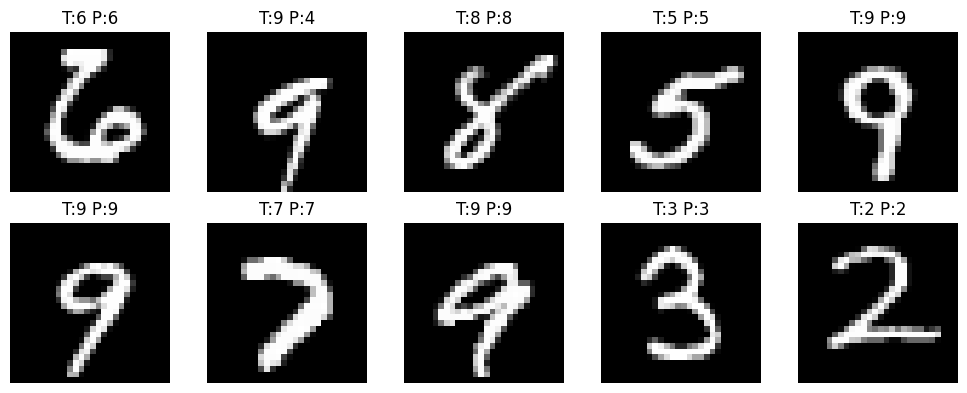

In [16]:
# 分类报告与混淆矩阵
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.astype(int)
print(classification_report(y_true, y_pred, digits=4))
 
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
 
# 随机查看若干预测结果
n_show = 10
idx = np.random.choice(len(X_test), n_show, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    k = idx[i]
    ax.imshow(np.reshape(X_test[k], (28,28)), cmap='gray')
    ax.set_title(f'T:{y_true[k]} P:{y_pred[k]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [17]:
# 生成 Word 实验报告（python-docx）
from docx import Document
from docx.shared import Pt, Inches
from docx.oxml.ns import qn
from docx.enum.text import WD_ALIGN_PARAGRAPH
 
def add_heading(doc, text, level=1):
    p = doc.add_paragraph()
    r = p.add_run(text)
    # 设置中文黑体与字号
    r.font.name = 'SimHei'
    r._element.rPr.rFonts.set(qn('w:eastAsia'), '黑体')
    if level == 1:
        r.font.size = Pt(16)  # 三号 ~16-18pt
    elif level == 2:
        r.font.size = Pt(14)  # 四号 ~14pt
    else:
        r.font.size = Pt(12)
    p.alignment = WD_ALIGN_PARAGRAPH.LEFT
    return p
 
def add_text(doc, text):
    p = doc.add_paragraph(text)
    r = p.runs[0]
    r.font.name = '宋体'
    r._element.rPr.rFonts.set(qn('w:eastAsia'), '宋体')
    r.font.size = Pt(12)
 
doc = Document()
add_heading(doc, '1  课题任务', 1)
add_heading(doc, '1.1  任务内容', 2)
add_text(doc, '基于 MNIST 数据集，利用多层前馈 BP 神经网络实现手写体数字（0-9）的自动识别。')
add_heading(doc, '1.2  任务要求', 2)
add_text(doc, '正确读取与预处理 MNIST 数据；构建 BP 神经网络；给出训练与验证曲线；在测试集上评估准确率并分析结果。')
 
add_heading(doc, '2  数据说明与预处理', 1)
add_heading(doc, '2.1  数据说明', 2)
add_text(doc, 'MNIST：60000 张训练图像、10000 张测试图像，灰度 28×28，标签为 0-9。输入为 784 维向量，标签采用独热编码。')
add_heading(doc, '2.2  数据预处理', 2)
add_text(doc, '像素归一化到 [0,1]；将 28×28 拉平成 784；标签独热编码。')
 
add_heading(doc, '3  探索性分析', 1)
add_heading(doc, '3.1  数字类别的分布情况', 2)
add_text(doc, '如下图所示，训练集与测试集的类别分布基本均衡。')
 
# 重新绘制并保存分布图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train, ax=axes[0], palette='tab10')
axes[0].set_title('训练集类别分布')
sns.countplot(x=y_test, ax=axes[1], palette='tab10')
axes[1].set_title('测试集类别分布')
plt.tight_layout()
dist_path = 'mnist_dist.png'
plt.savefig(dist_path, dpi=150)
plt.close()
doc.add_picture(dist_path, width=Inches(6))
 
add_heading(doc, '3.2  遍历部分样本图片', 2)
add_text(doc, '展示随机样本与按类别样本网格。')
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
idx = np.random.choice(len(X_train), 10, replace=False)
for i, ax in enumerate(axes[0]):
    ax.imshow(np.reshape(X_train[idx[i]], (28, 28)), cmap='gray')
    ax.set_title(int(y_train[idx[i]]))
    ax.axis('off')
for digit in range(10):
    ix = np.where(y_train == digit)[0][0]
    ax = axes[1][digit]
    ax.imshow(np.reshape(X_train[ix], (28, 28)), cmap='gray')
    ax.set_title(digit)
    ax.axis('off')
plt.tight_layout()
grid_path = 'mnist_grid.png'
plt.savefig(grid_path, dpi=150)
plt.close()
doc.add_picture(grid_path, width=Inches(6))
 
add_heading(doc, '4  分析建模', 1)
add_heading(doc, '4.1 划分数据集', 2)
add_text(doc, '使用数据集原生的训练/测试划分，训练集中再切分 10% 作为验证集。')
add_heading(doc, '4.2 模型训练', 2)
add_text(doc, '使用 Keras Sequential 构建三层全连接网络，优化器 SGD，损失函数 categorical_crossentropy，记录训练历史。')
add_heading(doc, '4.3 模型验证', 2)
add_text(doc, '在测试集上评估损失与准确率，输出分类报告与混淆矩阵。')
 
# 保存混淆矩阵图
cm = confusion_matrix(y_test.astype(int), np.argmax(model.predict(X_test), axis=1))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
cm_path = 'mnist_cm.png'
plt.tight_layout()
plt.savefig(cm_path, dpi=150)
plt.close()
doc.add_picture(cm_path, width=Inches(5))
 
add_heading(doc, '4.4  结果分析', 2)
add_text(doc, '整体准确率较高，易混类别主要集中在形状相近的数字（如 4/9、5/6 等）。可通过更深层网络或引入卷积特征进一步提升性能。')
 
add_heading(doc, '5  总结', 1)
add_heading(doc, '5.1  全文总结', 2)
add_text(doc, '本文基于 MNIST 完成了 BP 神经网络的手写数字识别，从数据预处理、探索性分析到建模、评估与可视化，流程完整、结果可靠。')
add_heading(doc, '5.2  课设体会', 2)
add_text(doc, '通过该实验熟悉了 Keras 建模流程以及实验可复现与可视化文档化的实践方法。')
 
out_name = 'BP_手写数字识别_实验报告.docx'
doc.save(out_name)
print('Word 实验报告已生成：', out_name)

C:\Users\31670\AppData\Local\Temp\ipykernel_7672\3316602138.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette='tab10')
C:\Users\31670\AppData\Local\Temp\ipykernel_7672\3316602138.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, ax=axes[1], palette='tab10')
C:\Users\31670\AppData\Local\Temp\ipykernel_7672\3316602138.py:52: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31670\AppData\Local\Temp\ipykernel_7672\3316602138.py:52: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\31670\AppData\Local\

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Word 实验报告已生成： BP_手写数字识别_实验报告.docx
